# Be a Geochronologist for a Day!

### Geochronology: An Introduction and Methods

Geochronology is one of the branches of geology that deals very heavily with geologic time. Geochronologists (like Sid, Steve, and Jenna!) spend a lot of their research efforts determining the ages of rocks, minerals, and fossils. Such ages, when placed in the context of where the rocks/minerals came from and their surrounding environment, help us better understand the timing of geologic events and Earth's history. Dating rock layers in a canyon can tell us the timing of their deposition, dating volcanic rocks can indicate the timing of eruptions, dating fault gouge can inform us when past earthquakes occurred, and more.

As you will have explored in the at-home excercises from the lab, we can determine relative ages of rock layers by comparing them to nearby layers. However, often we want to know an absolute age. To determine the absolute age of a mineral, geochronologists use **radiometric dating** techniques. Radiometric dating involves measuring the decay of naturally occuring radioactive isotopes in minerals. For example, the uranium-lead method measures the decay of uranium isotopes into stable lead isotopes. Another common method is potassium-argon dating, which measures the decay of a radioactive isotope of potassium into a stable argon daughter product.

### Question 1: Look up a radiometric dating method of your choice and describe it. 

**In your answer, be sure to include**

- **the parent and daughter elements (specific isotopes!). Include relevant half-lives**
- **how these elements are measured (this doesn't need to be detailed! Just a statement about the type of instruments geochronologists typically use)**
- **an example of a case where this method was applied (i.e. if you find a cool resesarch study, mention it!)**

*Answer Here*

### Thermochronology: An Introduction and Python Application

Thermochronology is a specific branch of geochronology that, as the name implies, studies the thermal history of rocks. That means that in addition to determing **when** the rock formed, we're also now interested in when the rock cooled below a certain temperature.

In calculating a geochronologic age, one assumes that the daughter product of radioactive decay is retained in the mineral structure for us to measure. However, in reality, such retention is thermally controlled. Daughter products will continue to be lost from a mineral structure by diffusion until that mineral is cooled below the **closure temperature**, or the temperature below which both the parent and daughter isotopes will be completely retained. Different mineral and isotope systems have characteristic closure temperatures; thus, for a specific rock sample, a variety of chronometers can be used to determine the time at which the rock existed within different temperature ranges. Since temperature is a function of depth below the surface, the depth of the rock at different points can be modeled.

Below are some common geo/thermo chronometers and their closure temperatures.

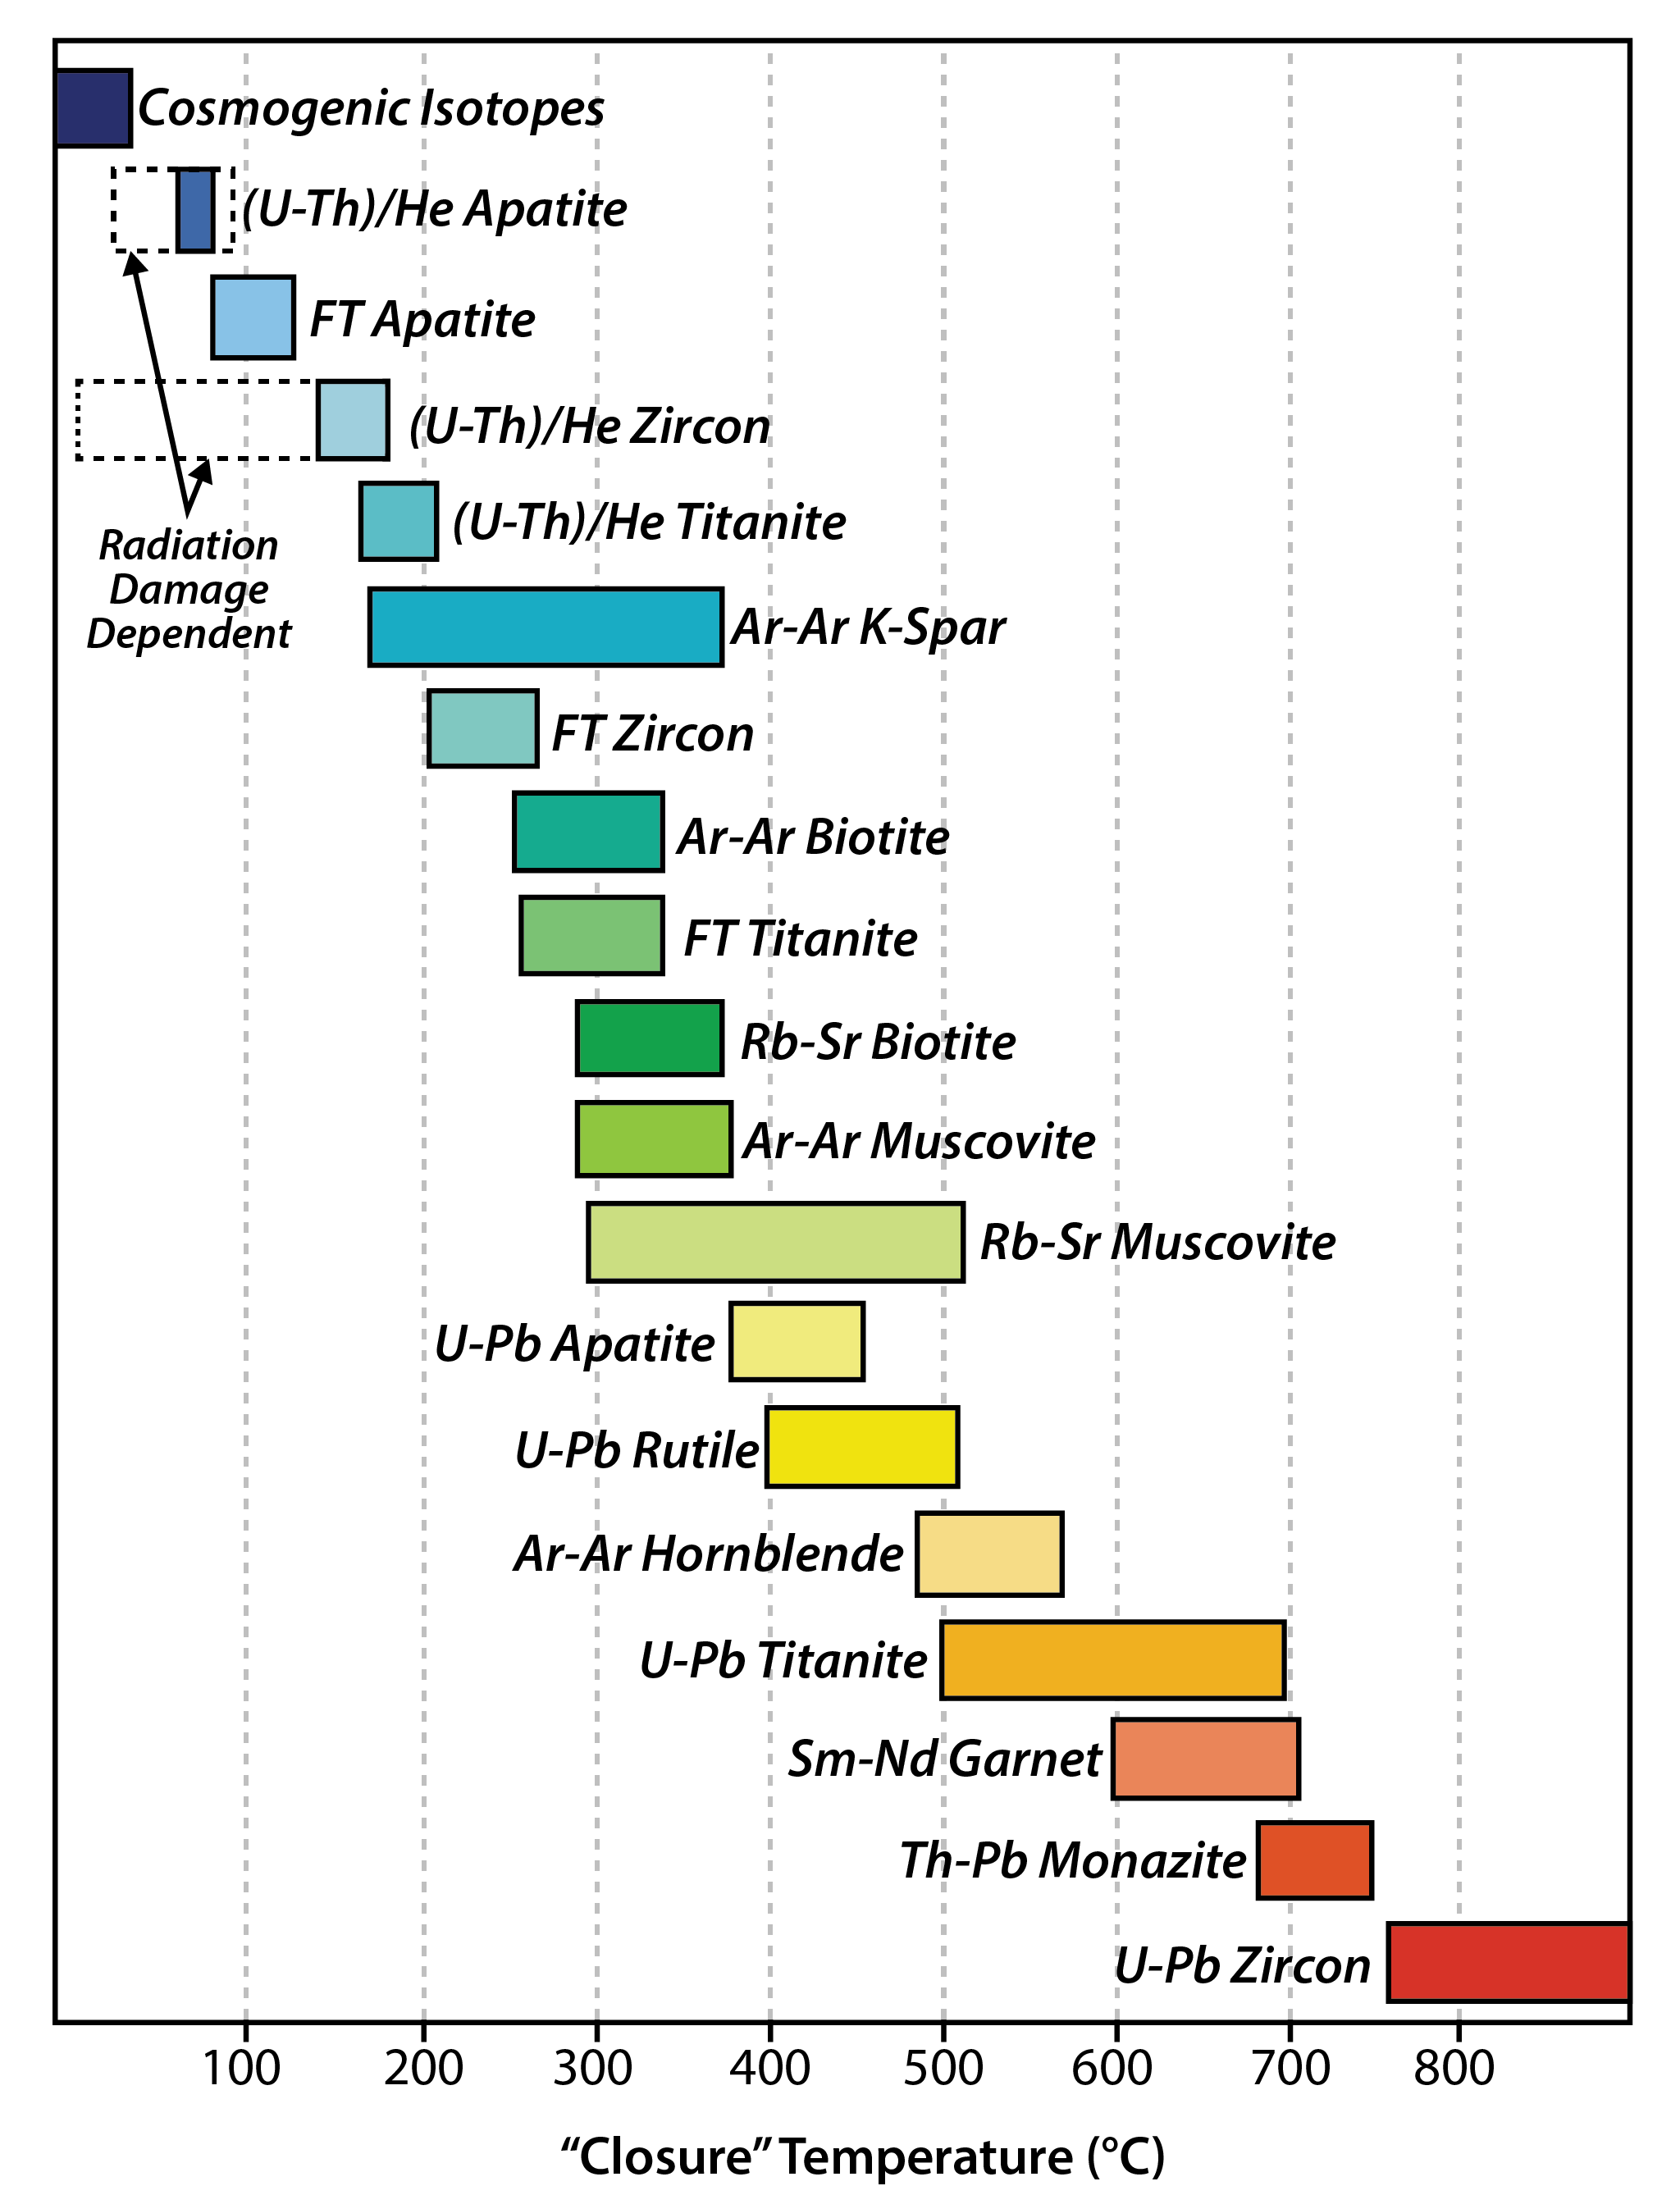

*(Source: Potsdam HeThermo Lab)*

As you can see, closure temperatures are generally a *range*. With errors, measured ages are also typically a range! Thus, an age value for a particular thermochronometer gives us a **constraint box** through which a time-temperature path must pass. What we mean when we say time-temperature path is that we can imagine that we are going to plot a history for a particular rock, where we have time on the x-axis (from some number of millions of years ago to present) and temperature (which can correlate to depth) on the y-axis. Ideally, we would want to be able to draw a single path that can show how this rock has gone through different temperature regions/depths over time. If we measure a variety of thermochronometers, we can get multiple constraint boxes, which allows us to use modeling techniques to predict such paths. One example of how this is done is shown below:

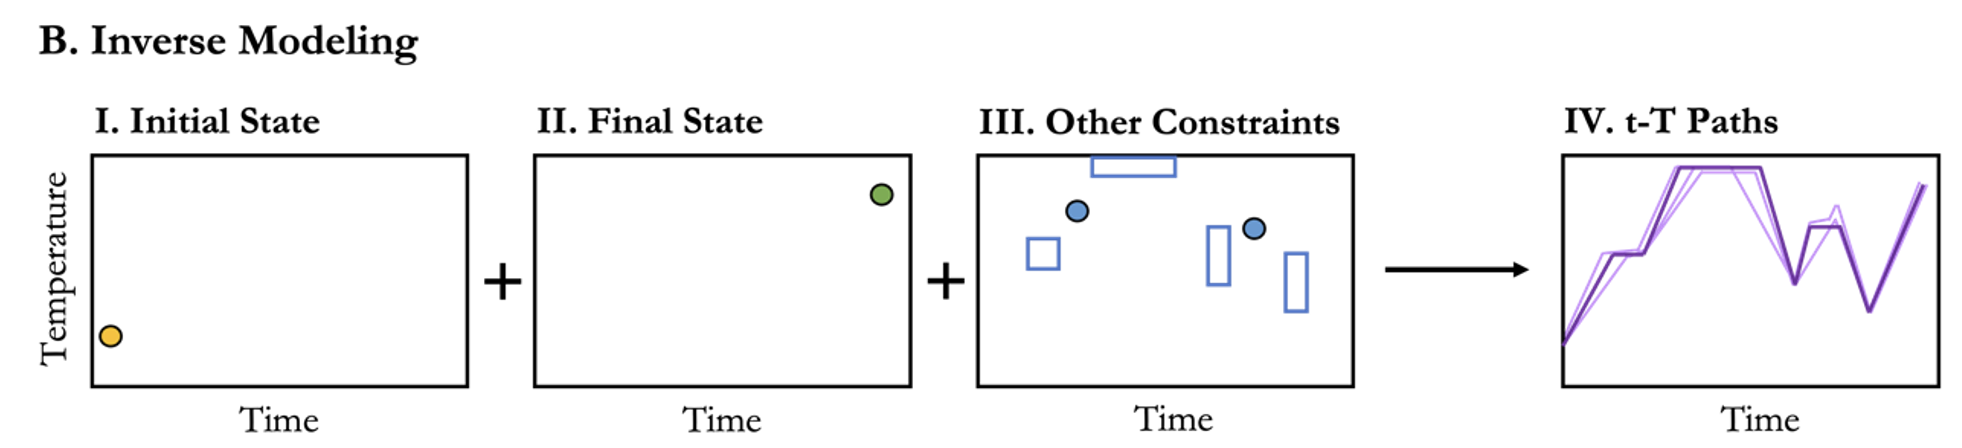

*(Source: Jenna's undergrad thesis)*

### Question 2: An Example of Thermochronologic Modeling

Let's explore this idea of modeling time-temperature paths further by generating some of our own! As we're doing so, we're going to think about a really "hot topic" in geology right now: the "Great Unconformity". The "Great Unconformity" refers to the approximately one billion years of missing geologic record between unfossiliferous Precambrian (4.6 Ga to 541 Ma) and fossiliferous Phanerozoic (538.8 Ma to present) stratigraphic layers. Prior studies suggest that the Great Unconformity represents as much as 25 km of eroded rock! To date, scientists have not yet been able to determine the exact cause of this erosion nor its timing, although a few hypotheses have come to the forefront of this debate.

One hypothesis suggests that major glacier movements during Snowball Earth (717 - 635 Ma) was the source of this massive erosion. A competing hypothesis presents tectonics as the source of erosion, such as that associated with the Pan-African Orogeny during the Edicarian-Cambrian transition (~540 Ma). For the exercise below, we'll use data from a paper that argues the latter. I've posted the relevant data on Canvas - you don't need to read the papers, but if you're interested: https://www.pnas.org/doi/abs/10.1073/pnas.1913131117 and https://www.pnas.org/doi/full/10.1073/pnas.2208451119. For fairness, here is the response from a team of researchers who support the first hypothesis (again, you don't need to read, I'm just including these links in case you are interested!): https://www.pnas.org/doi/full/10.1073/pnas.2209946119.

Below, we're going to use thermochronological constraints determined by Flowers et. al. to generate time-temperature paths related to the precambrian basement rock. When this basement rock was at the surface (temperature of 0-20ish), erosion could have been occuring to create the "Great Unconformity". On the other hand, when it was at a higher temperature (at depth), we can assume erosion could **not** have been occuring. 

The majority of the code has been written for you. Just try to read through it and run it. If you see a "TO DO", that indicates you may need to write or complete some code. There should only be two such statements. Finally, at the end, answer the questions to interpret the final plot.

In [15]:
# If any of these don't run, you may need to do a -> pip install <-

import numpy as np
import random as r
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [16]:
# Like last time, I'll provide some functions to help make the later code easier
# Don't worry if you don't understand the code!
# It could be helpful to read the comments explaining each function, though

# This defines a constraint box for the model
class TtBox:
    def __init__(self,Tmin,Tmax,tmin,tmax):
        self.Tmin = Tmin
        self.Tmax = Tmax
        self.tmin = tmin
        self.tmax = tmax

# Monte Carlo simulation to generate possible time-temperature paths
def draw(boxes):
    
    num = len(boxes)*2-1
    T = np.zeros(num)
    t = np.zeros(num)
    
    for i in range(1,len(boxes)):
        current_box = boxes[i]
        j = 2*(i-1)+1
        T[j] = r.random() * (current_box.Tmax - current_box.Tmin) + current_box.Tmin
        t[j] = r.random() * (current_box.tmax - current_box.tmin) + current_box.tmin
        
    for i in range(2,num-1,2):
        T[i] = r.random() * (T[i+1]-T[i-1]) + T[i-1]
        t[i] = r.random() * (t[i+1]-t[i-1]) + t[i-1]
    
    for k in range(0,len(boxes)):
        if T[k] == 0 and t[k] == 0:
            T[k] = None
            t[k] = None
            
    return t,T

# calculates how "good" a generated time-temperature path is
# defines good as how much of the path falls within the constraint boxes
def calculate_fit(t, T, boxes):
    inside_count = 0
    total_points = len(T)

    for i in range(len(T)):
        if T[i] is not None and t[i] is not None:
            for box in boxes:
                if box.Tmin <= T[i] <= box.Tmax and box.tmin <= t[i] <= box.tmax:
                    inside_count += 1
                    break

    fit = (inside_count / total_points) * 100
    return fit

To start, we need to define the constraint boxes we'll use to generate time-temperature paths. The formula for defining a box is:

*TtBox(min_temp, max_temp, min_age, max_age)*

I've defined the first two for you!

In [21]:
Pikes_Peak_at_Surface = TtBox(0, 20, 64, 68)
Flowers_et_al = TtBox(0,30,500,750)

# TO DO: define the remaining TtBox objects using the data provided on Canvas
# ***IMPORTANT: don't change the variable names!
Ancestral_Rockies_Burial_2 = 
Ancestral_Rockies_Burial = 
Fountain_Fm_Exposure = 
Paleozoic_burial_2 = 
Paleozoic_burial = 
Sawatch = 
KspAr_cooling = 
zircon_cooling = 
BtAr_cooling = 

In [27]:
boxes = [zircon_cooling,BtAr_cooling,KspAr_cooling,Flowers_et_al,Sawatch,Paleozoic_burial,Paleozoic_burial_2,
         Fountain_Fm_Exposure,Ancestral_Rockies_Burial,Ancestral_Rockies_Burial_2,Pikes_Peak_at_Surface]

Now we'll generate 250 possible time-temperature paths and calculate how good of a fit each is

In [31]:
runs = []
for _ in range(250):
    t, T = draw(boxes) # Generate Path
    fit = calculate_fit(t, T, boxes) # Calculate Fit
    runs.append((fit, t, T))
    
# Sort by fit
runs.sort(key=lambda x: x[0])

Let's plot our results! I've written most of the plotting code - it's just up to you to use what you learned about pyplot in the first week to set the limits for the axes and give them labels.

In [ ]:
f = plt.figure()
ax = f.add_subplot(111)

# Adding blue patches for the three major glaciations during snowball earth
ax.add_patch(Rectangle((659, 0),58,500,fc='#5EF0EA')) # Sturtian: 717 - 659 Ma
ax.add_patch(Rectangle((635, 0),6,500,fc='#5EF0EA')) # Marinoan 635 - 641 Ma
ax.add_patch(Rectangle((579.5, 0),1,500,fc='#5EF0EA')) # Gaskiers 580 Ma

# Plotting generated time-temperature paths
for i, (fit, t, T) in enumerate(runs):
    if i < 225:
        plt.plot(t, T, color='#6dcc9c', alpha=0.5)  # Pink for lowest 225 fits
    elif i < 249:
        plt.plot(t, T, color='#ec7fd4', alpha=0.8)  # Green for next 24
    else:
        plt.plot(t, T, color='k', linewidth=2)  # Black for best fit
        
# Drawing constraint boxes
for box in boxes:
    plt.plot([box.tmin, box.tmin, box.tmax, box.tmax, box.tmin],[box.Tmin, box.Tmax, box.Tmax, box.Tmin, box.Tmin],color='red', linestyle='--', linewidth=2)
    
# TO DO: 
# (1) Define reasonable x-axis limits (what time range, in Ma, are we looking at?)
# (2) Define reasonable y-axis limits (what temperatures are we looking at?)
# (3) Label both the x and y axis

# write code here





# Inverting the axes
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

The above plot shows calculated time-temperature paths for the basement rock. The green paths are the worst fits, the pink are the good fits, and the black path is the best fit. The constraint boxes are shown in red.

Note that this is an overly simplified example of this type of modeling, so your plot will not look the same as the one in the paper. Additionally, more robust models will do many thousands of iterations. Given we are only doing 250, you can re-run all the above code and you may get a plot that looks quite different!

### Interpret the Plot

**Describe what you see in the plot. Explain the history of the precambrian basement in the context of both the Pan-African Orogeny (~540 Ma) and Snowball Earth (the major glaciations are shown in blue). What does your model suggest as the source of erosion below the "Great Unconformity"?**

*Answer Here*